In [1]:
# ============================================================
# CELL 1 — Imports & Setup
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pydicom
import cv2
import kagglehub
from glob import glob
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
 
plt.style.use('ggplot')
sns.set_palette("Set2")
 
print("All libraries imported successfully ✓")

All libraries imported successfully ✓


In [2]:
# ============================================================
# CELL 2 — Load Data (auto-detect path)
# ============================================================
_hub_path = kagglehub.competition_download('rsna-pneumonia-detection-challenge')
 
def _find_data_dir(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if 'stage_2_train_labels.csv' in filenames:
            return dirpath
    return None
 
DATA_DIR = _find_data_dir(_hub_path)
if DATA_DIR is None:
    DATA_DIR = '/kaggle/input/rsna-pneumonia-detection-challenge'
 
TRAIN_IMAGES_DIR = os.path.join(DATA_DIR, 'stage_2_train_images')
 
print(f"DATA_DIR  : {DATA_DIR}")
print(f"Files     : {os.listdir(DATA_DIR)}\n")
 
labels_df     = pd.read_csv(os.path.join(DATA_DIR, 'stage_2_train_labels.csv'))
class_info_df = pd.read_csv(os.path.join(DATA_DIR, 'stage_2_detailed_class_info.csv'))
 
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nLabels shape     : {labels_df.shape}")
print(f"Class info shape : {class_info_df.shape}")
print("\n--- Labels Sample ---")
print(labels_df.head())
print("\n--- Class Info Sample ---")
print(class_info_df.head())
print("\n--- Labels dtypes ---")
print(labels_df.dtypes)
 

DATA_DIR  : /kaggle/input/competitions/rsna-pneumonia-detection-challenge
Files     : ['stage_2_train_images', 'stage_2_sample_submission.csv', 'stage_2_detailed_class_info.csv', 'GCP Credits Request Link - RSNA.txt', 'stage_2_train_labels.csv', 'stage_2_test_images']

DATASET OVERVIEW

Labels shape     : (30227, 6)
Class info shape : (30227, 2)

--- Labels Sample ---
                              patientId      x      y  width  height  Target
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    NaN    NaN    NaN     NaN       0
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd    NaN    NaN    NaN     NaN       0
2  00322d4d-1c29-4943-afc9-b6754be640eb    NaN    NaN    NaN     NaN       0
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5    NaN    NaN    NaN     NaN       0
4  00436515-870c-4b36-a041-de91049b9ab4  264.0  152.0  213.0   379.0       1

--- Class Info Sample ---
                              patientId                         class
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6  No Lung Opacity / Not Normal


In [3]:
# ============================================================
# CELL 3 — Missing Values & Basic Stats
# ============================================================
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
print("\nLabels nulls:\n",     labels_df.isnull().sum())
print("\nClass info nulls:\n", class_info_df.isnull().sum())
 
print("\n" + "=" * 60)
print("UNIQUE PATIENTS")
print("=" * 60)
print(f"Unique patientIds in labels    : {labels_df['patientId'].nunique()}")
print(f"Unique patientIds in class_info: {class_info_df['patientId'].nunique()}")

MISSING VALUES

Labels nulls:
 patientId        0
x            20672
y            20672
width        20672
height       20672
Target           0
dtype: int64

Class info nulls:
 patientId    0
class        0
dtype: int64

UNIQUE PATIENTS
Unique patientIds in labels    : 26684
Unique patientIds in class_info: 26684


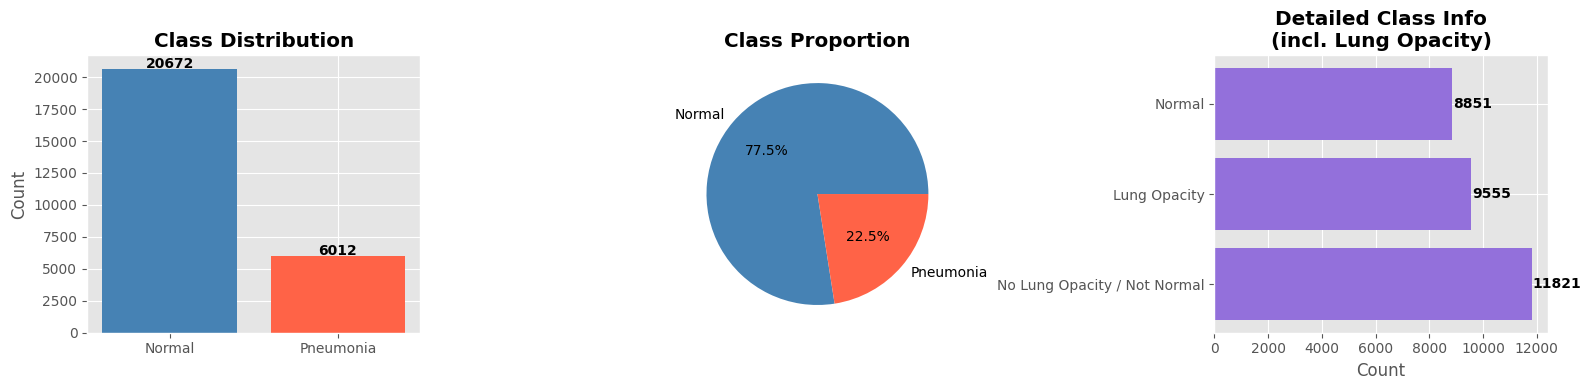


Detailed class breakdown:
class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64

Class imbalance ratio: 3.44:1  (Normal:Pneumonia)


In [4]:
# ============================================================
# CELL 4 — EDA: Class Distribution
# ============================================================
# One row per patient
patient_labels = labels_df.drop_duplicates('patientId')[['patientId', 'Target']].copy()
patient_labels['Label'] = patient_labels['Target'].map({0: 'Normal', 1: 'Pneumonia'})
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
# --- Count bar ---
counts = patient_labels['Label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
 
# --- Pie ---
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'])
axes[1].set_title('Class Proportion', fontweight='bold')
 
# --- Detailed class info (3 classes including Lung Opacity) ---
detail = class_info_df['class'].value_counts()
axes[2].barh(detail.index, detail.values, color='mediumpurple')
axes[2].set_title('Detailed Class Info\n(incl. Lung Opacity)', fontweight='bold')
axes[2].set_xlabel('Count')
for i, v in enumerate(detail.values):
    axes[2].text(v + 30, i, str(v), va='center', fontweight='bold')
 
plt.tight_layout()
plt.show()
 
print("\nDetailed class breakdown:")
print(detail)
print(f"\nClass imbalance ratio: {counts['Normal']/counts['Pneumonia']:.2f}:1  (Normal:Pneumonia)")
 

Total bounding box annotations : 9555
Positive patients              : 6012

Boxes per patient:
1    2614
2    3266
3     119
4      13
Name: count, dtype: int64

Bbox stats:
         width   height       area  aspect_ratio
count  9555.00  9555.00    9555.00       9555.00
mean    218.47   329.27   77523.45          0.79
std      59.29   157.75   51807.69          0.36
min      40.00    45.00    2320.00          0.22
25%     177.00   203.00   37535.50          0.53
50%     217.00   298.00   64829.00          0.69
75%     259.00   438.00  106491.50          0.96
max     528.00   942.00  371184.00          4.36


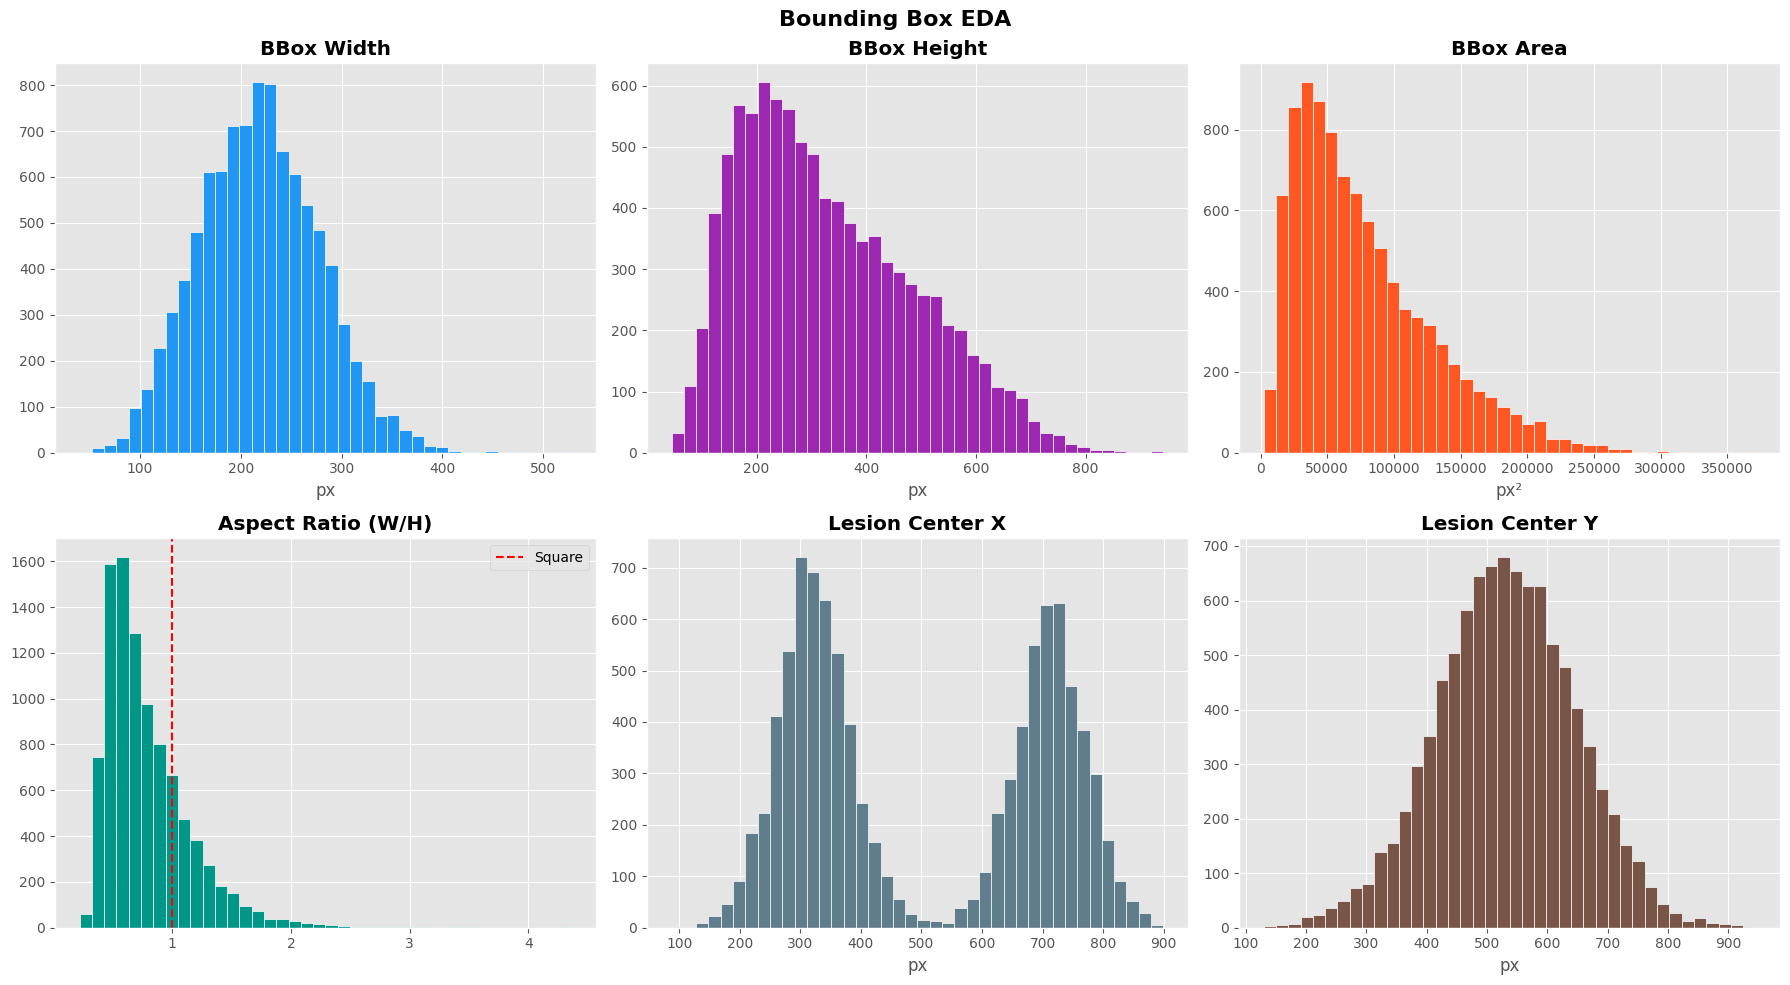

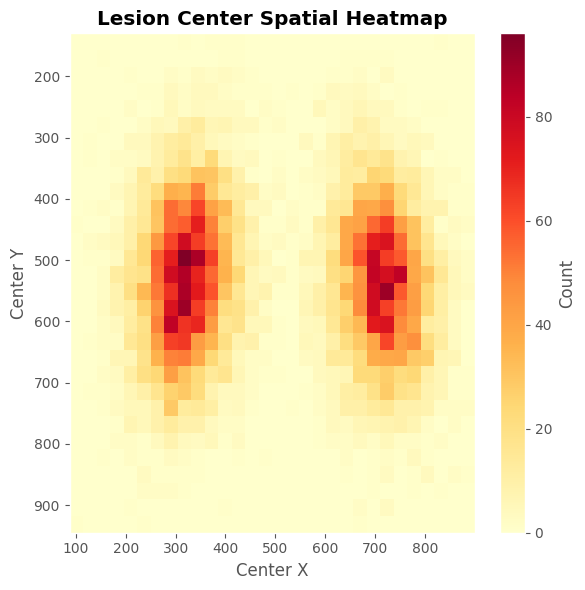

In [5]:
# ============================================================
# CELL 5 — EDA: Bounding Box Analysis
# ============================================================
positive_df = labels_df[labels_df['Target'] == 1].copy()
positive_df['area']         = positive_df['width'] * positive_df['height']
positive_df['aspect_ratio'] = positive_df['width'] / positive_df['height']
positive_df['cx']           = positive_df['x'] + positive_df['width']  / 2
positive_df['cy']           = positive_df['y'] + positive_df['height'] / 2
 
print(f"Total bounding box annotations : {len(positive_df)}")
print(f"Positive patients              : {positive_df['patientId'].nunique()}")
print(f"\nBoxes per patient:\n{positive_df.groupby('patientId').size().value_counts().sort_index()}")
print(f"\nBbox stats:\n{positive_df[['width','height','area','aspect_ratio']].describe().round(2)}")
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
 
axes[0,0].hist(positive_df['width'],        bins=40, color='#2196F3', edgecolor='white')
axes[0,0].set_title('BBox Width',           fontweight='bold'); axes[0,0].set_xlabel('px')
 
axes[0,1].hist(positive_df['height'],       bins=40, color='#9C27B0', edgecolor='white')
axes[0,1].set_title('BBox Height',          fontweight='bold'); axes[0,1].set_xlabel('px')
 
axes[0,2].hist(positive_df['area'],         bins=40, color='#FF5722', edgecolor='white')
axes[0,2].set_title('BBox Area',            fontweight='bold'); axes[0,2].set_xlabel('px²')
 
axes[1,0].hist(positive_df['aspect_ratio'], bins=40, color='#009688', edgecolor='white')
axes[1,0].set_title('Aspect Ratio (W/H)',   fontweight='bold')
axes[1,0].axvline(1.0, color='red', linestyle='--', label='Square')
axes[1,0].legend()
 
axes[1,1].hist(positive_df['cx'], bins=40, color='#607D8B', edgecolor='white')
axes[1,1].set_title('Lesion Center X',      fontweight='bold'); axes[1,1].set_xlabel('px')
 
axes[1,2].hist(positive_df['cy'], bins=40, color='#795548', edgecolor='white')
axes[1,2].set_title('Lesion Center Y',      fontweight='bold'); axes[1,2].set_xlabel('px')
 
plt.suptitle('Bounding Box EDA', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Spatial heatmap
fig, ax = plt.subplots(figsize=(6, 6))
h = ax.hist2d(positive_df['cx'], positive_df['cy'], bins=30, cmap='YlOrRd')
plt.colorbar(h[3], ax=ax, label='Count')
ax.set_title('Lesion Center Spatial Heatmap', fontweight='bold')
ax.set_xlabel('Center X'); ax.set_ylabel('Center Y')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


--- Generating Spatial Bounding Box Heatmap ---


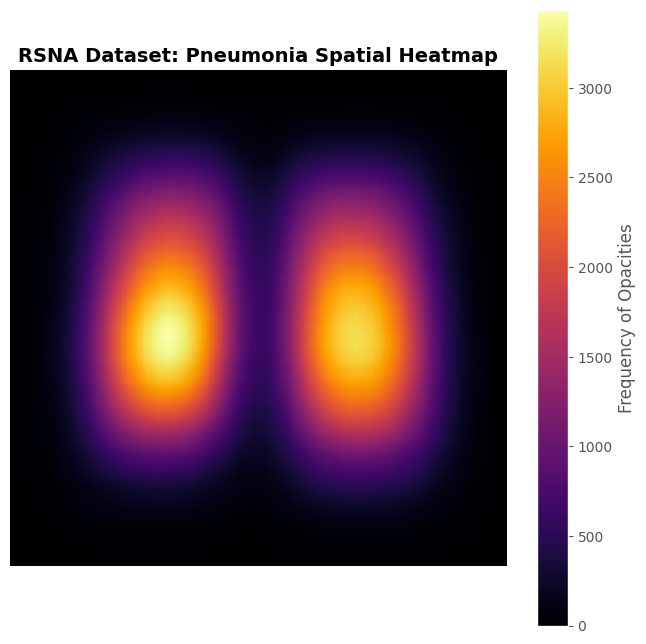

In [17]:
# EDA - Spatial Bounding Box Heatmap:

print("\n--- Generating Spatial Bounding Box Heatmap ---")

spatial_heatmap = np.zeros((1024, 1024))
pneumonia_cases = labels_df[labels_df['Target'] == 1].dropna(subset=['x', 'y', 'width', 'height'])

for _, row in pneumonia_cases.iterrows():
    x, y = int(row['x']), int(row['y'])
    w, h = int(row['width']), int(row['height'])
    x_end, y_end = min(x + w, 1024), min(y + h, 1024)
    spatial_heatmap[y:y_end, x:x_end] += 1

plt.figure(figsize = (8, 8))
plt.imshow(spatial_heatmap, cmap = 'inferno', interpolation = 'nearest')
plt.colorbar(label = 'Frequency of Opacities')
plt.title('RSNA Dataset: Pneumonia Spatial Heatmap', fontsize = 14, fontweight = 'bold')
plt.axis('off')
plt.show()

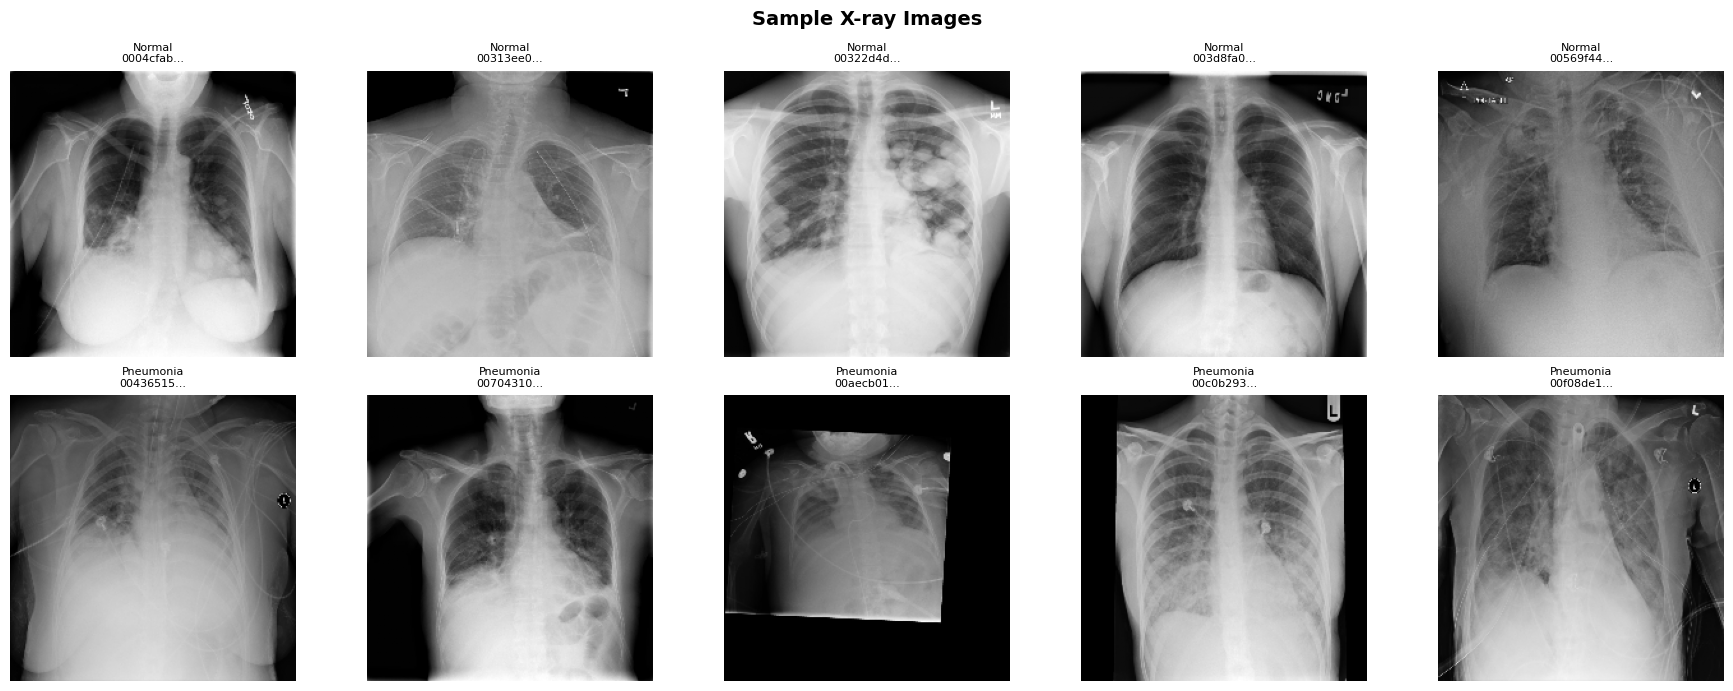

In [6]:
# ============================================================
# CELL 6 — EDA: Sample X-ray Images
# ============================================================
def load_dicom(patient_id, size=224):
    path_ = os.path.join(TRAIN_IMAGES_DIR, f"{patient_id}.dcm")
    ds    = pydicom.dcmread(path_)
    img   = ds.pixel_array.astype(np.float32)
    img   = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img   = cv2.resize(img, (size, size))
    return img
 
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, (label, name) in enumerate([(0, 'Normal'), (1, 'Pneumonia')]):
    samples = patient_labels[patient_labels['Target'] == label]['patientId'].values[:5]
    for j, pid in enumerate(samples):
        img = load_dicom(pid)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(f"{name}\n{pid[:8]}...", fontsize=8)
        axes[i, j].axis('off')
 
plt.suptitle('Sample X-ray Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 

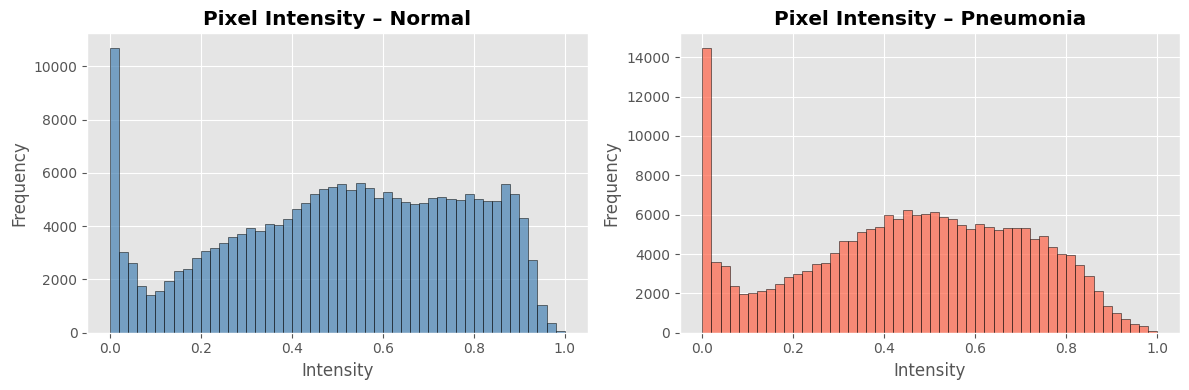

In [8]:
# ============================================================
# CELL 7 — EDA: Pixel Intensity Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
for idx, (label, name, color) in enumerate([(0, 'Normal',    'steelblue'),
                                             (1, 'Pneumonia', 'tomato')]):
    pids   = patient_labels[patient_labels['Target'] == label]['patientId'].values[:50]
    pixels = []
    for pid in pids:
        img = load_dicom(pid, size=64)
        pixels.extend(img.flatten())
    axes[idx].hist(pixels, bins=50, color=color, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Pixel Intensity – {name}', fontweight='bold')
    axes[idx].set_xlabel('Intensity')
    axes[idx].set_ylabel('Frequency')
 
plt.tight_layout()
plt.show()

BALANCED SAMPLING  (12,000 patients)

All class counts before sampling:
class
No Lung Opacity / Not Normal    11821
Normal                           8851
Lung Opacity                     6012
Name: count, dtype: int64

Sampled class distribution:
class
Normal          6000
Lung Opacity    6000
Name: count, dtype: int64

Sampled Target distribution:
Target
0    6000
1    6000
Name: count, dtype: int64

Total sampled patients: 12000


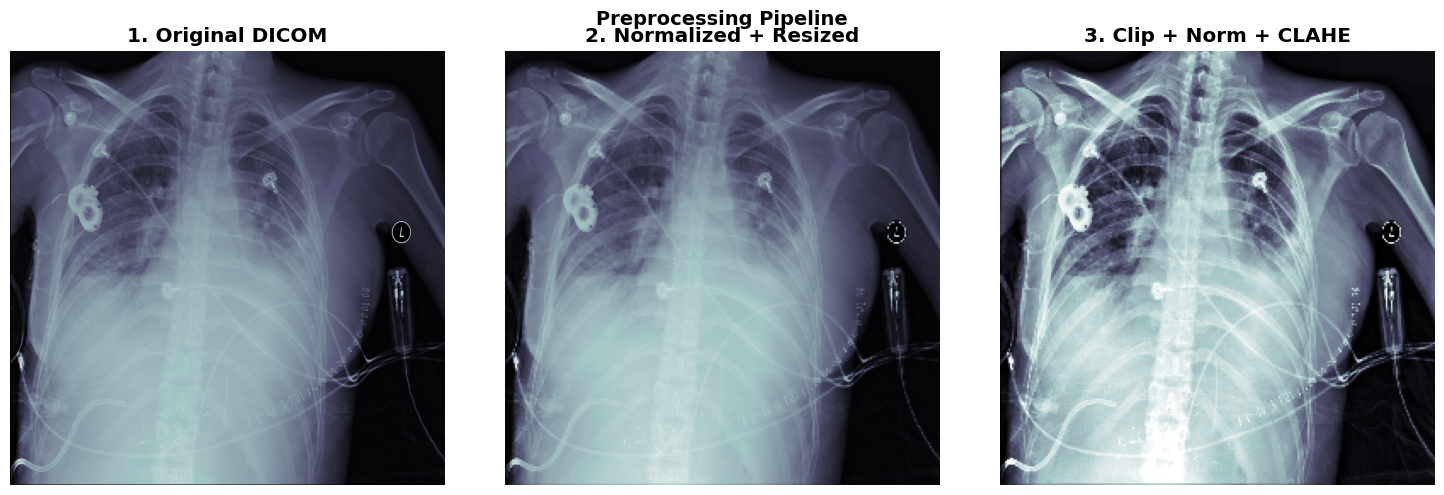

In [9]:
# ============================================================
# CELL 8 — PREPROCESSING: Build Balanced 12,000-patient Sample
#           6,000 Normal | 3,000 Pneumonia | 3,000 Lung Opacity
# ============================================================
print("=" * 60)
print("BALANCED SAMPLING  (12,000 patients)")
print("=" * 60)
 
# ── Merge class info (includes 'Lung Opacity') ──────────────
patient_full = patient_labels.merge(
    class_info_df.drop_duplicates('patientId')[['patientId', 'class']],
    on='patientId', how='left'
)
patient_full['class'] = patient_full['class'].fillna('Normal')
 
print("\nAll class counts before sampling:")
print(patient_full['class'].value_counts())
 
# ── Stratified sampling ─────────────────────────────────────
# Class breakdown:
#   Normal          →  Target=0, class='Normal'
#   Lung Opacity    →  Target=1, class='Lung Opacity'
#   Pneumonia       →  Target=1, class='Pneumonia'
# We split the 6,000 positive slots as: Lung Opacity + Pneumonia together
# If there are fewer than 3,000 of either, we take all available.
 
normal_pool       = patient_full[patient_full['class'] == 'Normal']
pneumonia_pool    = patient_full[patient_full['class'] == 'Pneumonia']
lung_opacity_pool = patient_full[patient_full['class'] == 'Lung Opacity']
 
n_normal       = 6000
n_pneumonia    = min(3000, len(pneumonia_pool))
n_lung_opacity = min(6000 - n_pneumonia, len(lung_opacity_pool))
 
sample_normal       = normal_pool.sample(n=n_normal,       random_state=42)
sample_pneumonia    = pneumonia_pool.sample(n=n_pneumonia,    random_state=42)
sample_lung_opacity = lung_opacity_pool.sample(n=n_lung_opacity, random_state=42)
 
sampled_df = pd.concat([sample_normal, sample_pneumonia, sample_lung_opacity], ignore_index=True)
sampled_df = sampled_df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
 
print(f"\nSampled class distribution:")
print(sampled_df['class'].value_counts())
print(f"\nSampled Target distribution:")
print(sampled_df['Target'].value_counts())
print(f"\nTotal sampled patients: {len(sampled_df)}")
 
 
# ── Preprocessing function ──────────────────────────────────
def preprocess_dicom(patient_id, img_size=256):
    """
    1. Read DICOM pixel array
    2. Percentile clipping (1st–99th) to remove outliers
    3. Min-max normalization → [0, 1]
    4. Resize to img_size × img_size
    5. CLAHE for contrast enhancement
    Returns float32 array in [0, 1]
    """
    fp  = os.path.join(TRAIN_IMAGES_DIR, f"{patient_id}.dcm")
    dcm = pydicom.dcmread(fp)
    img = dcm.pixel_array.astype(np.float32)
 
    # Percentile clipping
    p1, p99 = np.percentile(img, [1, 99])
    img = np.clip(img, p1, p99)
 
    # Normalize
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)
 
    # Resize
    img = cv2.resize(img, (img_size, img_size))
 
    # CLAHE
    img_uint8 = (img * 255).astype(np.uint8)
    clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_uint8)
 
    return img_clahe.astype(np.float32) / 255.0
 
 
# ── Demonstrate preprocessing on one image ──────────────────
demo_pid = sampled_df[sampled_df['Target'] == 1]['patientId'].iloc[0]
demo_fp  = os.path.join(TRAIN_IMAGES_DIR, f'{demo_pid}.dcm')
 
raw_img  = pydicom.dcmread(demo_fp).pixel_array.astype(np.float32)
proc_img = preprocess_dicom(demo_pid, img_size=256)
norm_img = (raw_img - raw_img.min()) / (raw_img.max() - raw_img.min())
norm_img = cv2.resize(norm_img, (256, 256))
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(raw_img,  cmap='bone'); axes[0].set_title('1. Original DICOM',         fontweight='bold'); axes[0].axis('off')
axes[1].imshow(norm_img, cmap='bone'); axes[1].set_title('2. Normalized + Resized',   fontweight='bold'); axes[1].axis('off')
axes[2].imshow(proc_img, cmap='bone'); axes[2].set_title('3. Clip + Norm + CLAHE',    fontweight='bold'); axes[2].axis('off')
plt.suptitle('Preprocessing Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 

In [10]:
# ============================================================
# CELL 9 — FEATURE ENGINEERING
# ============================================================
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)
 
# ── A. Bounding-box aggregate features per patient ──────────
bbox_agg = positive_df.groupby('patientId').agg(
    num_boxes    = ('area',         'count'),
    mean_width   = ('width',        'mean'),
    mean_height  = ('height',       'mean'),
    mean_area    = ('area',         'mean'),
    total_area   = ('area',         'sum'),
    mean_cx      = ('cx',           'mean'),
    mean_cy      = ('cy',           'mean'),
    mean_ar      = ('aspect_ratio', 'mean'),
).reset_index()
 
feature_df = sampled_df.merge(bbox_agg, on='patientId', how='left')
feature_df['num_boxes'] = feature_df['num_boxes'].fillna(0).astype(int)
 
# ── B. DICOM metadata (sample up to 500 for speed) ──────────
print("Extracting DICOM metadata (this may take a minute)…")
meta_records = []
for pid in feature_df['patientId'].values:
    fp = os.path.join(TRAIN_IMAGES_DIR, f'{pid}.dcm')
    if not os.path.exists(fp):
        continue
    try:
        dcm = pydicom.dcmread(fp)
        meta_records.append({
            'patientId'    : pid,
            'img_rows'     : int(dcm.Rows),
            'img_cols'     : int(dcm.Columns),
            'pixel_spacing': float(dcm.PixelSpacing[0]) if hasattr(dcm, 'PixelSpacing') else np.nan,
            'patient_age'  : str(getattr(dcm, 'PatientAge',   'UNK')),
            'patient_sex'  : str(getattr(dcm, 'PatientSex',   'UNK')),
            'view_position': str(getattr(dcm, 'ViewPosition', 'UNK')),
            'mean_pixel'   : float(dcm.pixel_array.mean()),
            'std_pixel'    : float(dcm.pixel_array.std()),
        })
    except Exception:
        pass
 
meta_df = pd.DataFrame(meta_records)
 
def parse_age(age_str):
    try:
        return int(''.join(filter(str.isdigit, str(age_str))))
    except:
        return np.nan
 
meta_df['age_years'] = meta_df['patient_age'].apply(parse_age)
feature_df = feature_df.merge(meta_df, on='patientId', how='left')
print(f"Metadata extracted for {len(meta_df)} patients.")
 
# ── C. Engineered features ───────────────────────────────────
 
# 1. Label encoding
le = LabelEncoder()
feature_df['sex_enc']   = le.fit_transform(feature_df['patient_sex'].fillna('U'))
feature_df['view_enc']  = le.fit_transform(feature_df['view_position'].fillna('UNK'))
feature_df['class_enc'] = le.fit_transform(feature_df['class'].fillna('Unknown'))
 
# 2. Age binning
age_bins   = [0, 18, 40, 60, 80, 120]
age_labels = ['<18', '18-40', '40-60', '60-80', '80+']
feature_df['age_group']     = pd.cut(feature_df['age_years'], bins=age_bins,
                                      labels=age_labels, right=False)
feature_df['age_group_enc'] = pd.Categorical(feature_df['age_group']).codes
 
# 3. Bbox coverage (fraction of image area covered by lesions)
feature_df['image_area_px'] = feature_df['img_rows'] * feature_df['img_cols']
feature_df['bbox_coverage'] = (
    feature_df['total_area'] / feature_df['image_area_px']
).fillna(0)
 
# 4. Normalized lesion center
feature_df['norm_cx'] = (feature_df['mean_cx'] / feature_df['img_cols']).fillna(0)
feature_df['norm_cy'] = (feature_df['mean_cy'] / feature_df['img_rows']).fillna(0)
 
# 5. Lesion side (left / right lung proxy)
feature_df['lesion_side'] = np.where(
    feature_df['num_boxes'] == 0, 'None',
    np.where(feature_df['norm_cx'] < 0.5, 'Left', 'Right')
)
 
# 6. Image quality / contrast
feature_df['contrast_ratio'] = (
    feature_df['std_pixel'] / (feature_df['mean_pixel'] + 1e-6)
)
 
# 7. Multi-lesion flag
feature_df['multi_lesion'] = (feature_df['num_boxes'] > 1).astype(int)
 
# 8. Lung Opacity binary flag
feature_df['is_lung_opacity'] = (feature_df['class'] == 'Lung Opacity').astype(int)
 
print("\nFinal feature set shape:", feature_df.shape)
print("\nSample rows:")
eng_cols = [
    'patientId', 'Target', 'class', 'class_enc',
    'age_years', 'age_group', 'age_group_enc',
    'sex_enc', 'view_enc',
    'num_boxes', 'multi_lesion', 'is_lung_opacity',
    'mean_width', 'mean_height', 'mean_area',
    'bbox_coverage', 'norm_cx', 'norm_cy', 'lesion_side',
    'mean_pixel', 'std_pixel', 'contrast_ratio',
]
print(feature_df[eng_cols].head(10).to_string())

FEATURE ENGINEERING
Extracting DICOM metadata (this may take a minute)…
Metadata extracted for 12000 patients.

Final feature set shape: (12000, 34)

Sample rows:
                              patientId  Target         class  class_enc  age_years age_group  age_group_enc  sex_enc  view_enc  num_boxes  multi_lesion  is_lung_opacity  mean_width  mean_height  mean_area  bbox_coverage   norm_cx   norm_cy lesion_side  mean_pixel  std_pixel  contrast_ratio
0  50c1e2e5-05ff-463d-999b-8ee02e6974b8       0        Normal          1         45     40-60              2        1         1          0             0                0         NaN          NaN        NaN       0.000000  0.000000  0.000000        None  128.043115  65.339847        0.510296
1  a4b449be-8c92-4191-aa74-cce130365f0e       1  Lung Opacity          0         24     18-40              1        0         0          1             0                1       242.0        198.0    47916.0       0.045696  0.602539  0.488281       Right 

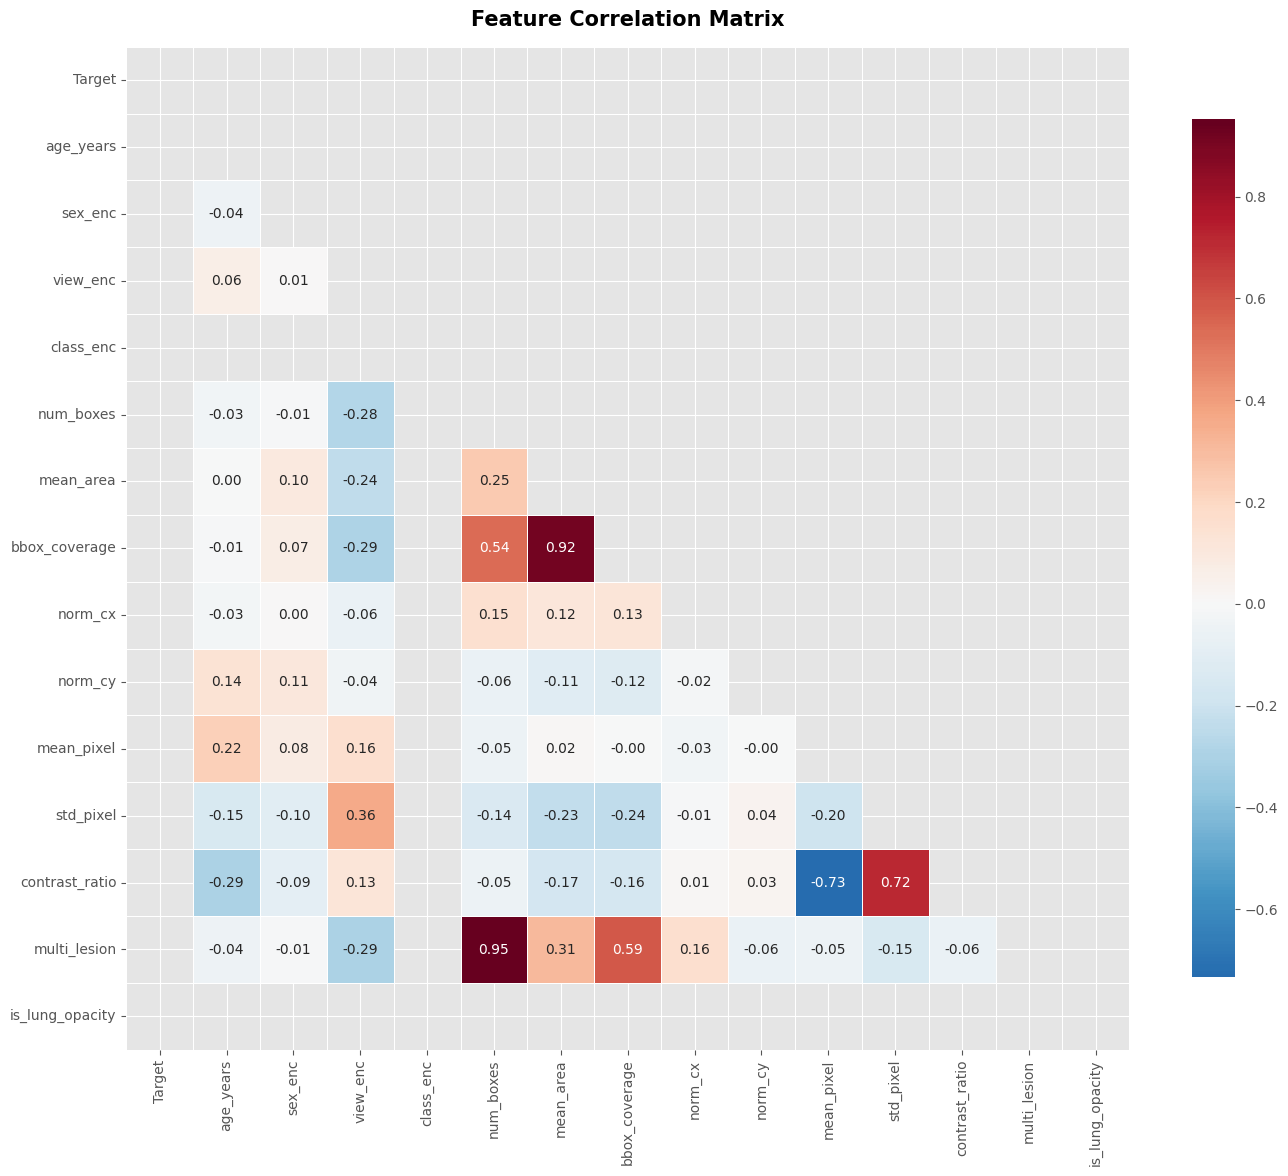

In [11]:
# ============================================================
# CELL 10 — Correlation Matrix
# ============================================================
numeric_cols = [
    'Target', 'age_years', 'sex_enc', 'view_enc', 'class_enc',
    'num_boxes', 'mean_area', 'bbox_coverage', 'norm_cx', 'norm_cy',
    'mean_pixel', 'std_pixel', 'contrast_ratio',
    'multi_lesion', 'is_lung_opacity'
]
corr_matrix = feature_df[numeric_cols].dropna().corr()
 
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, mask=mask, ax=ax,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
 

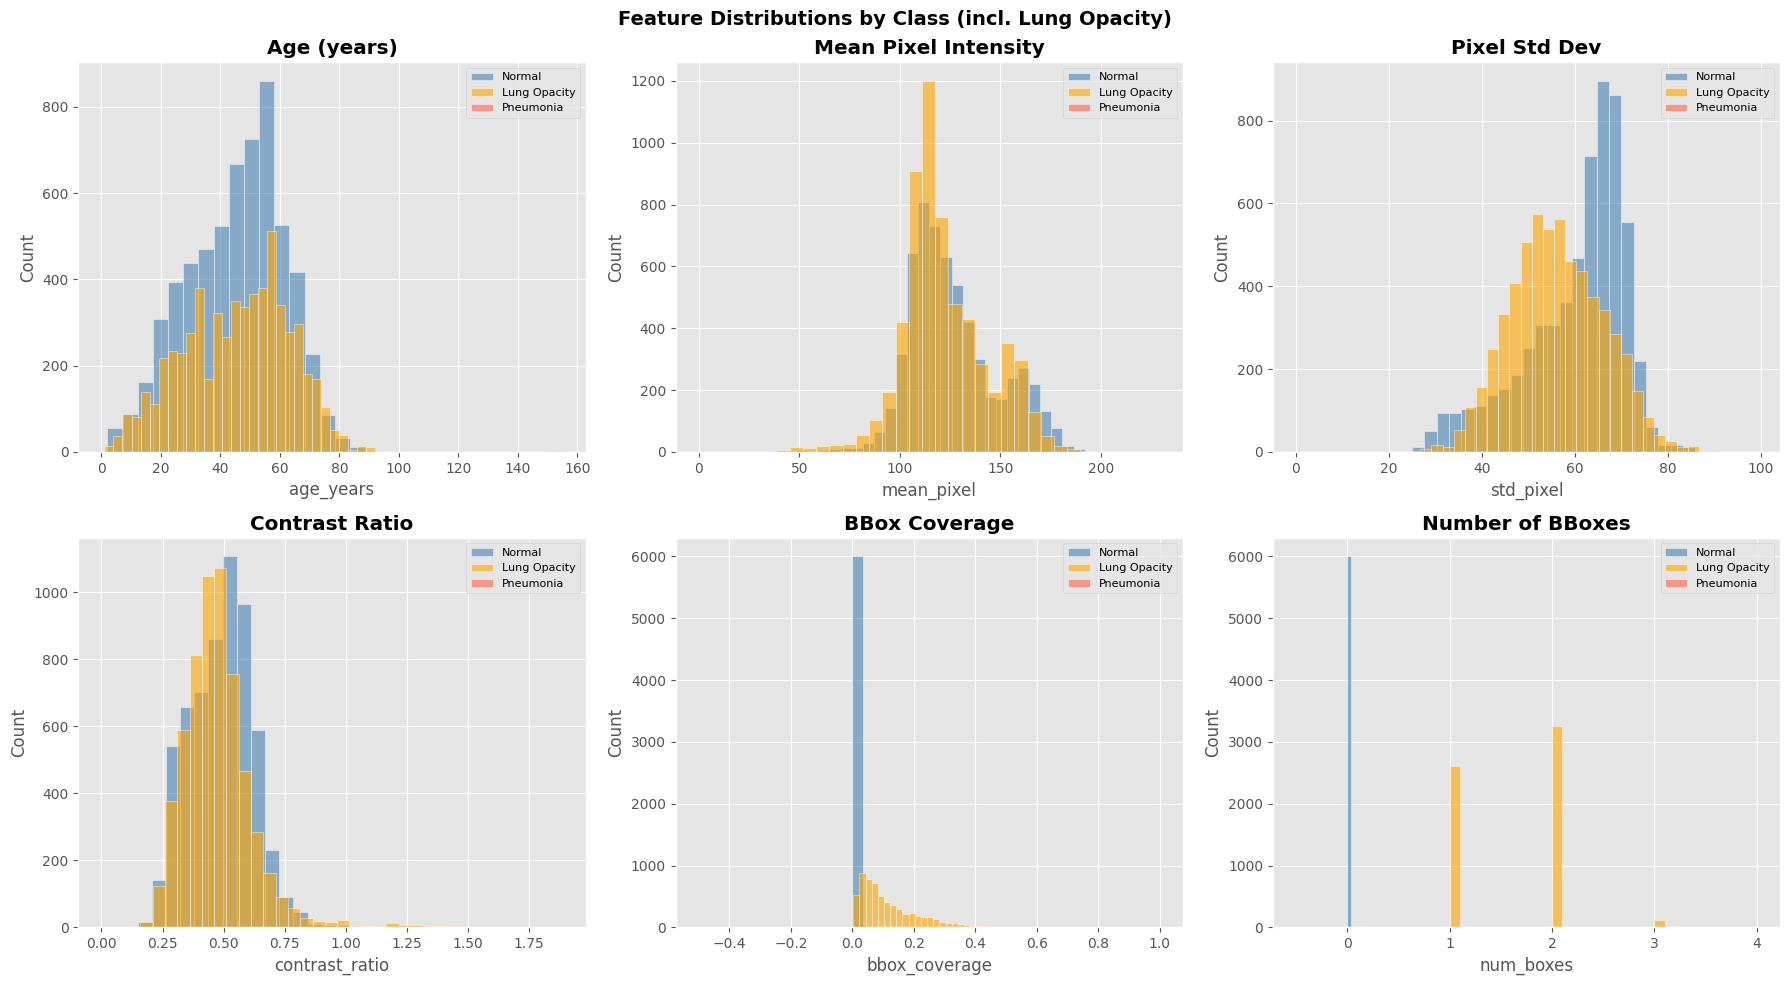

In [12]:
# ============================================================
# CELL 11 — Feature Distributions by Class
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
 
plot_features = [
    ('age_years',      'Age (years)'),
    ('mean_pixel',     'Mean Pixel Intensity'),
    ('std_pixel',      'Pixel Std Dev'),
    ('contrast_ratio', 'Contrast Ratio'),
    ('bbox_coverage',  'BBox Coverage'),
    ('num_boxes',      'Number of BBoxes'),
]
 
for ax, (feat, title) in zip(axes.flat, plot_features):
    for cls, color in [('Normal','steelblue'), ('Lung Opacity','orange'), ('Pneumonia','tomato')]:
        data = feature_df[feature_df['class'] == cls][feat].dropna()
        ax.hist(data, bins=30, alpha=0.6, label=cls, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
 
plt.suptitle('Feature Distributions by Class (incl. Lung Opacity)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 

In [16]:
# ============================================================
# CELL 12 — Train / Validation Split
# ============================================================

print("=" * 60)
print("TRAIN / VALIDATION SPLIT")
print("=" * 60)

train_ids, val_ids = train_test_split(
    feature_df['patientId'],
    test_size=0.2,
    random_state=42,
    stratify=feature_df['Target']
)

train_df = feature_df[
    feature_df['patientId'].isin(train_ids)
].reset_index(drop=True)

val_df = feature_df[
    feature_df['patientId'].isin(val_ids)
].reset_index(drop=True)

print(f"\nTrain size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")

print(f"\nTrain class distribution:\n{train_df['class'].value_counts()}")
print(f"\nVal class distribution:\n{val_df['class'].value_counts()}")

# ============================================================
# 5-Fold Stratified Split
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("\n5-Fold Stratified Split summary:")

for fold, (tr_idx, vl_idx) in enumerate(
    skf.split(feature_df, feature_df['Target'])
):

    tr_t = feature_df.iloc[tr_idx]['Target'].value_counts()
    vl_t = feature_df.iloc[vl_idx]['Target'].value_counts()

    print(
        f"Fold {fold+1}: "
        f"Train Pos={tr_t.get(1,0)}, Neg={tr_t.get(0,0)} | "
        f"Val Pos={vl_t.get(1,0)}, Neg={vl_t.get(0,0)}"
    )

# ============================================================
# Save Engineered Features
# ============================================================

feature_df[eng_cols].to_csv(
    'rsna_engineered_features.csv',
    index=False
)

print("\nSaved → rsna_engineered_features.csv")

# ============================================================
# Pipeline Complete
# ============================================================

print("\n" + "=" * 60)
print("PIPELINE COMPLETE ✓")
print("=" * 60)

TRAIN / VALIDATION SPLIT

Train size : 9600
Val size   : 2400

Train class distribution:
class
Normal          4800
Lung Opacity    4800
Name: count, dtype: int64

Val class distribution:
class
Lung Opacity    1200
Normal          1200
Name: count, dtype: int64

5-Fold Stratified Split summary:
Fold 1: Train Pos=4800, Neg=4800 | Val Pos=1200, Neg=1200
Fold 2: Train Pos=4800, Neg=4800 | Val Pos=1200, Neg=1200
Fold 3: Train Pos=4800, Neg=4800 | Val Pos=1200, Neg=1200
Fold 4: Train Pos=4800, Neg=4800 | Val Pos=1200, Neg=1200
Fold 5: Train Pos=4800, Neg=4800 | Val Pos=1200, Neg=1200

Saved → rsna_engineered_features.csv

PIPELINE COMPLETE ✓
